# HW06-ICA Part B :: Binary Classification Metrics

COSC 6373 -- Adam Nelson-Archer, 2140122

This notebook follows the Part B tasks using transfer learning with ResNet50 on Horses vs Camels.


## Setup and imports

In [6]:
from __future__ import annotations

import os
import random
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    auc,
    confusion_matrix,
    precision_score,
    recall_score,
    roc_curve,
)
from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

SEED = 6373
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU available:", len(tf.config.list_physical_devices("GPU")) > 0)
print("Working directory:", os.getcwd())


TensorFlow: 2.16.2
GPU available: False
Working directory: c:\Users\PC\Desktop\projects_and_code\School\COSC6373\HW6\Part_B


## Dataset paths and split helpers

Expected extracted dataset layout:

- `DATA_ROOT/train/<horse-class-folder>/...`
- `DATA_ROOT/train/<camel-class-folder>/...`
- `DATA_ROOT/test/<horse-class-folder>/...`
- `DATA_ROOT/test/<camel-class-folder>/...`

If your class folder names are not exactly `horses` / `camels`, this code still maps labels using name matching.


In [8]:
NOTEBOOK_DIR = Path.cwd()
DATA_ROOT = (NOTEBOOK_DIR / "data" / "horses_camels").resolve()

TRAIN_DIR = DATA_ROOT / "train"
TEST_DIR = DATA_ROOT / "test"

print("DATA_ROOT:", DATA_ROOT)
print("TRAIN_DIR exists:", TRAIN_DIR.exists())
print("TEST_DIR exists:", TEST_DIR.exists())

if not TRAIN_DIR.exists() or not TEST_DIR.exists():
    raise FileNotFoundError(
        "Dataset not found. Put extracted Horses vs Camels data under "
        "HW6/Part_B/data/horses_camels with train/ and test/ folders."
    )


DATA_ROOT: C:\Users\PC\Desktop\projects_and_code\School\COSC6373\HW6\Part_B\data\horses_camels
TRAIN_DIR exists: True
TEST_DIR exists: True


In [9]:
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}


def infer_label_from_path(path: Path) -> int:
    """Map horse->0, camel->1 using folder name text."""
    token = path.parent.name.lower()
    if "horse" in token:
        return 0
    if "camel" in token:
        return 1
    raise ValueError(f"Cannot infer class label from folder name: {path.parent.name}")


def collect_image_paths(root_dir: Path) -> pd.DataFrame:
    rows = []
    for p in root_dir.rglob("*"):
        if p.is_file() and p.suffix.lower() in IMG_EXTS:
            y = infer_label_from_path(p)
            rows.append({"path": str(p), "label": int(y)})
    if not rows:
        raise ValueError(f"No images found under: {root_dir}")
    df = pd.DataFrame(rows)
    return df.sample(frac=1.0, random_state=SEED).reset_index(drop=True)


train_all_df = collect_image_paths(TRAIN_DIR)
test_df = collect_image_paths(TEST_DIR)

print("Total train images:", len(train_all_df))
print("Total test images:", len(test_df))
print("Train class counts:\n", train_all_df["label"].value_counts().sort_index())
print("Test class counts:\n", test_df["label"].value_counts().sort_index())


Total train images: 360
Total test images: 40
Train class counts:
 label
0    180
1    180
Name: count, dtype: int64
Test class counts:
 label
0    20
1    20
Name: count, dtype: int64


In [10]:
# Assignment requirement: build validation set from original training set,
# with 20 images per class.
val_n_per_class = 20

if (train_all_df["label"].value_counts() < val_n_per_class).any():
    raise ValueError("Not enough training images to sample 20 per class for validation.")

val_df = (
    train_all_df.groupby("label", group_keys=False)
    .apply(lambda g: g.sample(n=val_n_per_class, random_state=SEED))
    .reset_index(drop=True)
)

# Remove validation images from original training set by path.
train_df = train_all_df[~train_all_df["path"].isin(set(val_df["path"]))].reset_index(drop=True)


def balance_binary_df(df: pd.DataFrame, seed: int = SEED) -> pd.DataFrame:
    """Undersample to the minority class count so each split is balanced."""
    counts = df["label"].value_counts()
    if len(counts) != 2:
        raise ValueError(f"Expected 2 classes, found: {counts.to_dict()}")
    n = int(counts.min())
    out = (
        df.groupby("label", group_keys=False)
        .apply(lambda g: g.sample(n=n, random_state=seed))
        .sample(frac=1.0, random_state=seed)
        .reset_index(drop=True)
    )
    return out


# Validation is already exactly 20 per class, but we keep this explicit.
val_df = balance_binary_df(val_df)
train_df = balance_binary_df(train_df)
test_df = balance_binary_df(test_df)

print("Train split size:", len(train_df))
print("Validation split size:", len(val_df))
print("Test split size:", len(test_df))
print("\nTrain class counts:\n", train_df["label"].value_counts().sort_index())
print("\nValidation class counts:\n", val_df["label"].value_counts().sort_index())
print("\nTest class counts:\n", test_df["label"].value_counts().sort_index())


Train split size: 320
Validation split size: 40
Test split size: 40

Train class counts:
 label
0    160
1    160
Name: count, dtype: int64

Validation class counts:
 label
0    20
1    20
Name: count, dtype: int64

Test class counts:
 label
0    20
1    20
Name: count, dtype: int64


C:\Users\PC\AppData\Local\Temp\ipykernel_27720\3884273537.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(n=val_n_per_class, random_state=SEED))
C:\Users\PC\AppData\Local\Temp\ipykernel_27720\3884273537.py:26: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(n=n, random_state=seed))
C:\Users\PC\AppData\Local\Temp\ipykernel_27720\3884273537.py:26: Depreca

## Input pipeline

In [11]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 8
LR = 1e-4


def _load_and_preprocess(path: tf.Tensor, label: tf.Tensor):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32)
    img = preprocess_input(img)
    return img, label


def make_dataset(df: pd.DataFrame, one_hot: bool, training: bool) -> tf.data.Dataset:
    paths = df["path"].astype(str).values
    labels = df["label"].astype(np.int32).values
    if one_hot:
        labels = tf.one_hot(labels, depth=2)

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(buffer_size=len(df), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(_load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds


## Model builders

In [12]:
def build_bce_model(freeze_base: bool) -> tf.keras.Model:
    base = ResNet50(weights="imagenet", include_top=False, input_shape=(224, 224, 3), pooling="avg")
    base.trainable = not freeze_base

    inputs = tf.keras.Input(shape=(224, 224, 3))
    # Keep BN/internals frozen only when base is frozen; allow full updates otherwise.
    x = base(inputs, training=not freeze_base)
    outputs = layers.Dense(1, activation="sigmoid")(x)
    model = tf.keras.Model(inputs, outputs, name=f"resnet50_bce_{'frozen' if freeze_base else 'full'}")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LR),
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )
    return model


def build_cce_model(freeze_base: bool) -> tf.keras.Model:
    base = ResNet50(weights="imagenet", include_top=False, input_shape=(224, 224, 3), pooling="avg")
    base.trainable = not freeze_base

    inputs = tf.keras.Input(shape=(224, 224, 3))
    # Keep BN/internals frozen only when base is frozen; allow full updates otherwise.
    x = base(inputs, training=not freeze_base)
    outputs = layers.Dense(2, activation="softmax")(x)
    model = tf.keras.Model(inputs, outputs, name=f"resnet50_cce_{'frozen' if freeze_base else 'full'}")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LR),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


## Evaluation utilities (confusion matrix, precision, accuracy, sensitivity, specificity, ROC/AUC)

In [13]:
@dataclass
class EvalResult:
    accuracy: float
    precision: float
    sensitivity: float
    specificity: float
    auc_score: float
    cm: np.ndarray
    fpr: np.ndarray
    tpr: np.ndarray


def collect_predictions(model: tf.keras.Model, ds: tf.data.Dataset, mode: str):
    y_true_batches = []
    y_prob_batches = []

    for x_batch, y_batch in ds:
        y_hat = model.predict(x_batch, verbose=0)
        if mode == "bce":
            y_true = tf.cast(tf.reshape(y_batch, [-1]), tf.int32).numpy()
            y_prob = tf.reshape(y_hat, [-1]).numpy()
        elif mode == "cce":
            y_true = tf.argmax(y_batch, axis=1).numpy()
            y_prob = y_hat[:, 1]
        else:
            raise ValueError(f"Unknown mode: {mode}")

        y_true_batches.append(y_true)
        y_prob_batches.append(y_prob)

    y_true = np.concatenate(y_true_batches)
    y_prob = np.concatenate(y_prob_batches)
    y_pred = (y_prob >= 0.5).astype(np.int32)
    return y_true, y_prob, y_pred


def evaluate_binary(y_true: np.ndarray, y_prob: np.ndarray, y_pred: np.ndarray) -> EvalResult:
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    sensitivity = recall_score(y_true, y_pred, zero_division=0)
    specificity = tn / max((tn + fp), 1)

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc_score = auc(fpr, tpr)

    return EvalResult(
        accuracy=float(accuracy),
        precision=float(precision),
        sensitivity=float(sensitivity),
        specificity=float(specificity),
        auc_score=float(auc_score),
        cm=cm,
        fpr=fpr,
        tpr=tpr,
    )


def diagnose_fit(history: tf.keras.callbacks.History) -> str:
    train_loss = np.array(history.history["loss"], dtype=float)
    val_loss = np.array(history.history["val_loss"], dtype=float)

    if len(train_loss) < 2:
        return "insufficient epochs to diagnose"

    train_drop = train_loss[0] - train_loss[-1]
    val_drop = val_loss[0] - val_loss[-1]
    gap = val_loss[-1] - train_loss[-1]

    if train_drop > 0 and gap > 0.2 and val_drop < train_drop * 0.3:
        return "likely overfitted"
    if train_drop < 0.05 and val_drop < 0.05:
        return "likely underfitted"
    return "reasonably well-trained"


def print_model_report(name: str, eval_result: EvalResult, history: tf.keras.callbacks.History):
    print(f"\n{name}")
    print(f"fit diagnosis: {diagnose_fit(history)}")
    print(f"accuracy:    {eval_result.accuracy:.4f}")
    print(f"precision:   {eval_result.precision:.4f}")
    print(f"sensitivity: {eval_result.sensitivity:.4f}")
    print(f"specificity: {eval_result.specificity:.4f}")
    print(f"roc auc:     {eval_result.auc_score:.4f}")


def plot_learning_curve(history: tf.keras.callbacks.History, title: str):
    plt.figure(figsize=(6, 4))
    plt.plot(history.history["loss"], marker="o", label="train loss")
    plt.plot(history.history["val_loss"], marker="o", label="val loss")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()


def plot_cm(cm: np.ndarray, title: str):
    fig, ax = plt.subplots(figsize=(4, 4))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["horse", "camel"])
    disp.plot(cmap="Blues", ax=ax, colorbar=False)
    ax.set_title(title)
    plt.tight_layout()


def plot_roc(fpr: np.ndarray, tpr: np.ndarray, auc_score: float, title: str):
    plt.figure(figsize=(5, 4))
    plt.plot(fpr, tpr, label=f"AUC={auc_score:.4f}")
    plt.plot([0, 1], [0, 1], "k--", alpha=0.7)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.legend(loc="lower right")
    plt.tight_layout()


## Run Model 1: BCE + sigmoid (frozen base)

- Dense(1, sigmoid)
- Binary cross-entropy
- Freeze all layers except classifier


Epoch 1/8
10/10 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step - accuracy: 0.4663 - loss: 0.7716 - val_accuracy: 0.4250 - val_loss: 0.8475
Epoch 2/8
10/10 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.5433 - loss: 0.7411 - val_accuracy: 0.4750 - val_loss: 0.8040
Epoch 3/8
10/10 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.6114 - loss: 0.6620 - val_accuracy: 0.5500 - val_loss: 0.7578
Epoch 4/8
10/10 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.6260 - loss: 0.6426 - val_accuracy: 0.6000 - val_loss: 0.7161
Epoch 5/8
10/10 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.6325 - loss: 0.6040 - val_accuracy: 0.6250 - val_loss: 0.6784
Epoch 6/8
10/10 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.6925 - loss: 0.5572 - val_accuracy: 0.6500 - val_loss: 0.6421
Epoch 7/8
10/10 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.7199 - loss: 0.5328 - val_accuracy: 0.7000 - val_loss: 0.6099
Epoch 8/8
10/10 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.7575 - loss: 0.4767 - val_accuracy: 0.7250 - val_loss: 0.5817


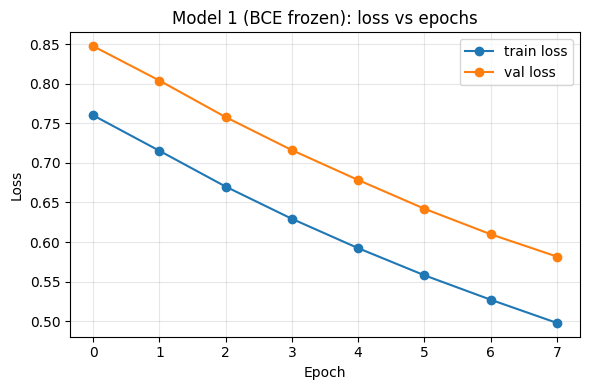

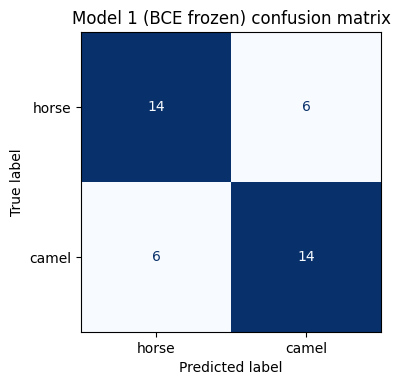

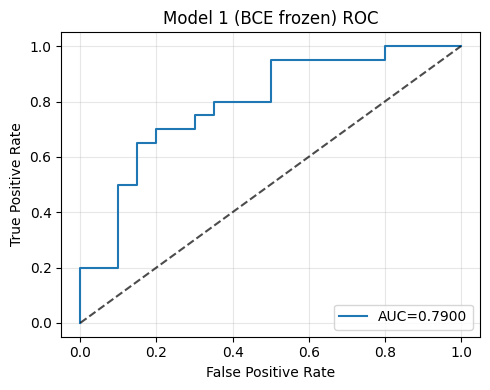

In [14]:
train_ds_bce = make_dataset(train_df, one_hot=False, training=True)
val_ds_bce = make_dataset(val_df, one_hot=False, training=False)
test_ds_bce = make_dataset(test_df, one_hot=False, training=False)

model1_bce_frozen = build_bce_model(freeze_base=True)
history1 = model1_bce_frozen.fit(
    train_ds_bce,
    validation_data=val_ds_bce,
    epochs=EPOCHS,
    verbose=1,
)

plot_learning_curve(history1, "Model 1 (BCE frozen): loss vs epochs")
y_true_1, y_prob_1, y_pred_1 = collect_predictions(model1_bce_frozen, test_ds_bce, mode="bce")
eval1 = evaluate_binary(y_true_1, y_prob_1, y_pred_1)

plot_cm(eval1.cm, "Model 1 (BCE frozen) confusion matrix")
plot_roc(eval1.fpr, eval1.tpr, eval1.auc_score, "Model 1 (BCE frozen) ROC")
print_model_report("Model 1 (BCE frozen)", eval1, history1)


## Run Model 2: CCE + softmax (frozen base)

- Reinitialize with ImageNet weights
- Dense(2, softmax)
- One-hot labels + categorical cross-entropy
- Freeze all layers except classifier


Epoch 1/8
10/10 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step - accuracy: 0.5045 - loss: 0.8587 - val_accuracy: 0.6000 - val_loss: 0.7860
Epoch 2/8
10/10 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.5461 - loss: 0.7080 - val_accuracy: 0.5250 - val_loss: 0.7264
Epoch 3/8
10/10 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.6324 - loss: 0.6185 - val_accuracy: 0.5500 - val_loss: 0.6610
Epoch 4/8
10/10 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.6970 - loss: 0.5659 - val_accuracy: 0.6750 - val_loss: 0.5977
Epoch 5/8
10/10 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.7169 - loss: 0.5427 - val_accuracy: 0.7500 - val_loss: 0.5488
Epoch 6/8
10/10 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.7768 - loss: 0.4759 - val_accuracy: 0.7500 - val_loss: 0.5101
Epoch 7/8
10/10 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.8534 - loss: 0.4112 - val_accuracy: 0.7750 - val_loss: 0.4751
Epoch 8/8
10/10 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.8585 - loss: 0.3904 - val_accuracy: 0.8000 - val_loss: 0.4441


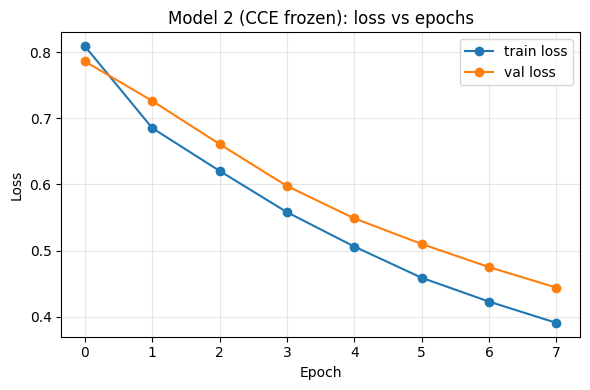

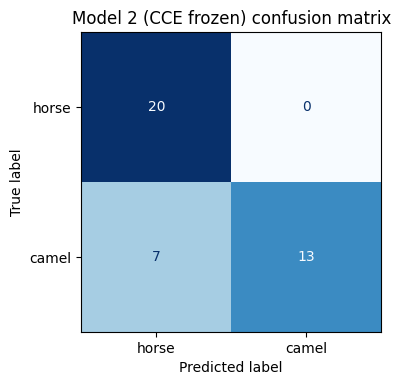

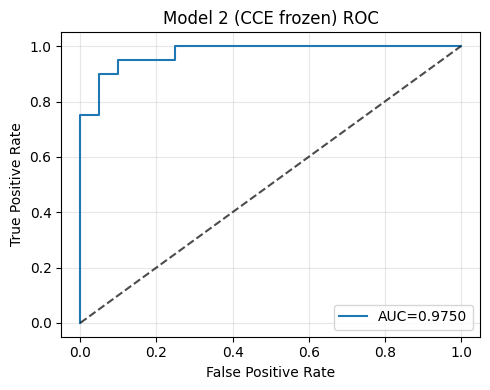

In [15]:
train_ds_cce = make_dataset(train_df, one_hot=True, training=True)
val_ds_cce = make_dataset(val_df, one_hot=True, training=False)
test_ds_cce = make_dataset(test_df, one_hot=True, training=False)

model2_cce_frozen = build_cce_model(freeze_base=True)
history2 = model2_cce_frozen.fit(
    train_ds_cce,
    validation_data=val_ds_cce,
    epochs=EPOCHS,
    verbose=1,
)

plot_learning_curve(history2, "Model 2 (CCE frozen): loss vs epochs")
y_true_2, y_prob_2, y_pred_2 = collect_predictions(model2_cce_frozen, test_ds_cce, mode="cce")
eval2 = evaluate_binary(y_true_2, y_prob_2, y_pred_2)

plot_cm(eval2.cm, "Model 2 (CCE frozen) confusion matrix")
plot_roc(eval2.fpr, eval2.tpr, eval2.auc_score, "Model 2 (CCE frozen) ROC")
print_model_report("Model 2 (CCE frozen)", eval2, history2)


## Run Model 3A: full fine-tuning with BCE + sigmoid

- Reinitialize with ImageNet weights
- Train full model (no frozen layers)


Epoch 1/8
10/10 ━━━━━━━━━━━━━━━━━━━━ 105s 6s/step - accuracy: 0.6579 - loss: 0.6086 - val_accuracy: 0.8750 - val_loss: 0.2578
Epoch 2/8
10/10 ━━━━━━━━━━━━━━━━━━━━ 62s 6s/step - accuracy: 0.9988 - loss: 0.0419 - val_accuracy: 0.8750 - val_loss: 0.4111
Epoch 3/8
10/10 ━━━━━━━━━━━━━━━━━━━━ 63s 6s/step - accuracy: 1.0000 - loss: 0.0054 - val_accuracy: 0.9000 - val_loss: 0.6428
Epoch 4/8
10/10 ━━━━━━━━━━━━━━━━━━━━ 64s 6s/step - accuracy: 1.0000 - loss: 0.0029 - val_accuracy: 0.9000 - val_loss: 0.6590
Epoch 5/8
10/10 ━━━━━━━━━━━━━━━━━━━━ 72s 7s/step - accuracy: 1.0000 - loss: 9.6172e-04 - val_accuracy: 0.8750 - val_loss: 0.5170
Epoch 6/8
10/10 ━━━━━━━━━━━━━━━━━━━━ 67s 7s/step - accuracy: 1.0000 - loss: 7.3053e-04 - val_accuracy: 0.8750 - val_loss: 0.3775
Epoch 7/8
10/10 ━━━━━━━━━━━━━━━━━━━━ 64s 6s/step - accuracy: 1.0000 - loss: 8.8912e-04 - val_accuracy: 0.9250 - val_loss: 0.2772
Epoch 8/8
10/10 ━━━━━━━━━━━━━━━━━━━━ 65s 7s/step - accuracy: 1.0000 - loss: 5.8219e-04 - val_accuracy: 0.9250 - 

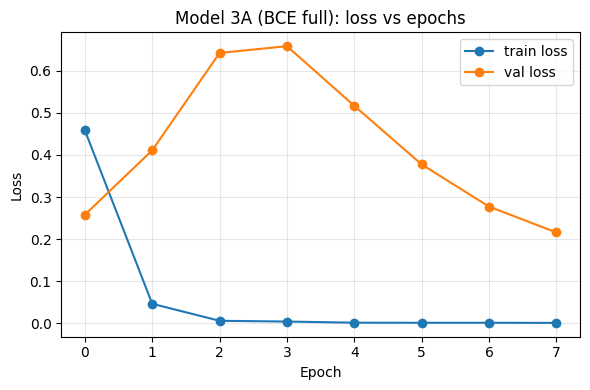

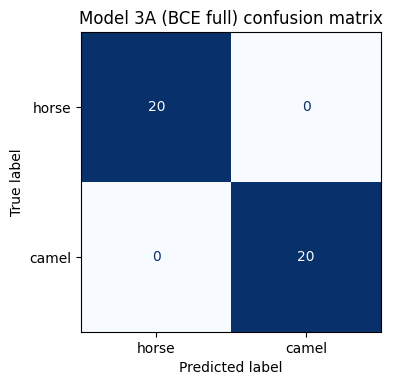

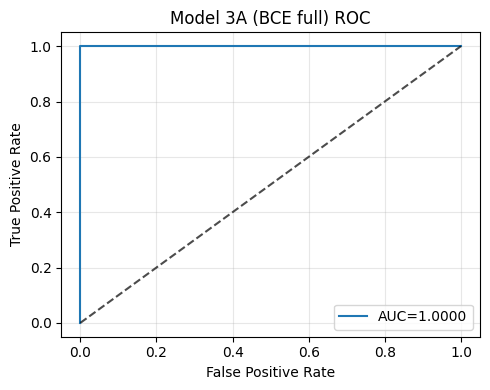

In [16]:
model3a_bce_full = build_bce_model(freeze_base=False)
history3a = model3a_bce_full.fit(
    train_ds_bce,
    validation_data=val_ds_bce,
    epochs=EPOCHS,
    verbose=1,
)

plot_learning_curve(history3a, "Model 3A (BCE full): loss vs epochs")
y_true_3a, y_prob_3a, y_pred_3a = collect_predictions(model3a_bce_full, test_ds_bce, mode="bce")
eval3a = evaluate_binary(y_true_3a, y_prob_3a, y_pred_3a)

plot_cm(eval3a.cm, "Model 3A (BCE full) confusion matrix")
plot_roc(eval3a.fpr, eval3a.tpr, eval3a.auc_score, "Model 3A (BCE full) ROC")
print_model_report("Model 3A (BCE full)", eval3a, history3a)


## Run Model 3B: full fine-tuning with CCE + softmax

- Reinitialize with ImageNet weights
- Train full model (no frozen layers)


Epoch 1/8
10/10 ━━━━━━━━━━━━━━━━━━━━ 97s 6s/step - accuracy: 0.7197 - loss: 0.5401 - val_accuracy: 0.8500 - val_loss: 0.5218
Epoch 2/8
10/10 ━━━━━━━━━━━━━━━━━━━━ 57s 6s/step - accuracy: 0.9961 - loss: 0.0255 - val_accuracy: 0.8500 - val_loss: 0.6818
Epoch 3/8
10/10 ━━━━━━━━━━━━━━━━━━━━ 58s 6s/step - accuracy: 1.0000 - loss: 0.0060 - val_accuracy: 0.8250 - val_loss: 1.2193
Epoch 4/8
10/10 ━━━━━━━━━━━━━━━━━━━━ 59s 6s/step - accuracy: 1.0000 - loss: 0.0021 - val_accuracy: 0.8250 - val_loss: 1.3195
Epoch 5/8
10/10 ━━━━━━━━━━━━━━━━━━━━ 59s 6s/step - accuracy: 1.0000 - loss: 5.5212e-04 - val_accuracy: 0.8500 - val_loss: 0.9713
Epoch 6/8
10/10 ━━━━━━━━━━━━━━━━━━━━ 60s 6s/step - accuracy: 1.0000 - loss: 4.4245e-04 - val_accuracy: 0.9000 - val_loss: 0.7532
Epoch 7/8
10/10 ━━━━━━━━━━━━━━━━━━━━ 66s 6s/step - accuracy: 1.0000 - loss: 6.6219e-04 - val_accuracy: 0.9000 - val_loss: 0.6123
Epoch 8/8
10/10 ━━━━━━━━━━━━━━━━━━━━ 63s 6s/step - accuracy: 1.0000 - loss: 3.9235e-04 - val_accuracy: 0.9250 - v

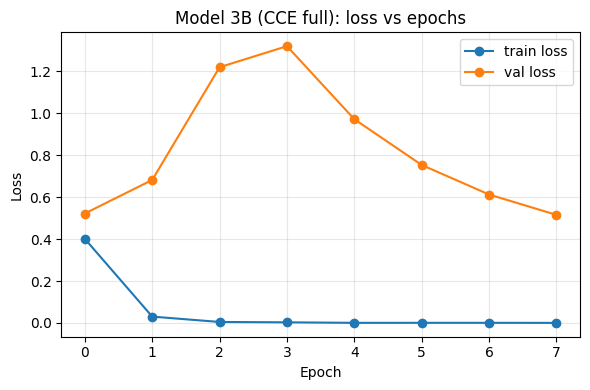

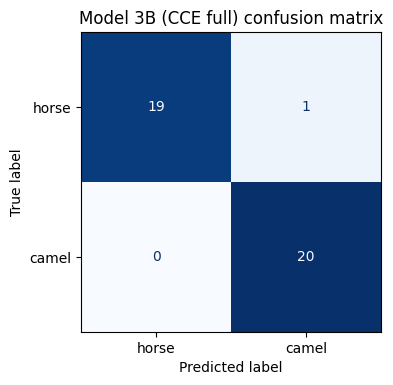

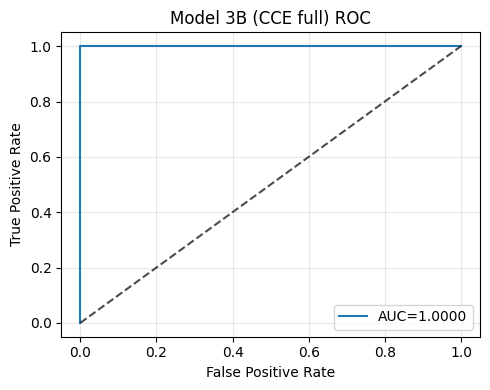

In [17]:
model3b_cce_full = build_cce_model(freeze_base=False)
history3b = model3b_cce_full.fit(
    train_ds_cce,
    validation_data=val_ds_cce,
    epochs=EPOCHS,
    verbose=1,
)

plot_learning_curve(history3b, "Model 3B (CCE full): loss vs epochs")
y_true_3b, y_prob_3b, y_pred_3b = collect_predictions(model3b_cce_full, test_ds_cce, mode="cce")
eval3b = evaluate_binary(y_true_3b, y_prob_3b, y_pred_3b)

plot_cm(eval3b.cm, "Model 3B (CCE full) confusion matrix")
plot_roc(eval3b.fpr, eval3b.tpr, eval3b.auc_score, "Model 3B (CCE full) ROC")
print_model_report("Model 3B (CCE full)", eval3b, history3b)


## Metrics summary table

In [18]:
summary_df = pd.DataFrame(
    [
        {"model": "M1 BCE frozen", **eval1.__dict__},
        {"model": "M2 CCE frozen", **eval2.__dict__},
        {"model": "M3A BCE full", **eval3a.__dict__},
        {"model": "M3B CCE full", **eval3b.__dict__},
    ]
)

summary_view = summary_df[["model", "accuracy", "precision", "sensitivity", "specificity", "auc_score"]]
summary_view = summary_view.sort_values(by="accuracy", ascending=False).reset_index(drop=True)
summary_view


,model,accuracy,precision,sensitivity,specificity,auc_score
0,M3A BCE full,1.000,1.000000,1.00,1.00,1.000
1,M3B CCE full,0.975,0.952381,1.00,0.95,1.000
2,M2 CCE frozen,0.825,1.000000,0.65,1.00,0.975
3,M1 BCE frozen,0.700,0.700000,0.70,0.70,0.790


## Auto-generated comparison paragraph

This cell produces the required written comparison using your trained model histories and metrics.
Run it after all four model training/evaluation cells.


In [19]:
# This comparison code block was generated using Claude 4.6, 
# for the purpose of helping analyze results generated by the above models.
# The written questions were created by me, Adam Nelson-Archer, but I wanted some
# confirmation of my analysis and results.

def convergence_summary(history: tf.keras.callbacks.History) -> str:
    train_loss = np.array(history.history["loss"], dtype=float)
    val_loss = np.array(history.history["val_loss"], dtype=float)

    if len(train_loss) < 2:
        return "insufficient epochs"

    val_std = float(np.std(np.diff(val_loss))) if len(val_loss) > 2 else 0.0
    stability = "stable" if val_std < 0.03 else "less stable"
    trend = "decreasing" if val_loss[-1] < val_loss[0] else "not clearly decreasing"
    return f"{stability} validation curve with {trend} loss"


def model_metric_phrase(name: str, ev: EvalResult) -> str:
    return (
        f"{name} (Acc={ev.accuracy:.3f}, Prec={ev.precision:.3f}, "
        f"Sens={ev.sensitivity:.3f}, Spec={ev.specificity:.3f}, AUC={ev.auc_score:.3f})"
    )


frozen_better = "BCE" if eval1.auc_score >= eval2.auc_score else "CCE"
full_better = "BCE" if eval3a.auc_score >= eval3b.auc_score else "CCE"

paragraph = f"""
BCE vs CCE (frozen classifier only): {model_metric_phrase('BCE frozen', eval1)} compared with
{model_metric_phrase('CCE frozen', eval2)}. Convergence behavior shows BCE as
{convergence_summary(history1)}, while CCE is {convergence_summary(history2)}. Under this setup,
{frozen_better} gives the stronger overall discrimination by AUC.

BCE vs CCE (full fine-tuning): {model_metric_phrase('BCE full', eval3a)} compared with
{model_metric_phrase('CCE full', eval3b)}. Convergence behavior shows BCE as
{convergence_summary(history3a)}, while CCE is {convergence_summary(history3b)}. Under full
fine-tuning, {full_better} gives the stronger overall discrimination by AUC.

Overall takeaway: across frozen and full fine-tuning settings, compare both threshold metrics
(accuracy/precision/sensitivity/specificity) and threshold-free ROC-AUC. The best submission
choice should prioritize the configuration that keeps both high final metrics and stable validation
loss behavior.
""".strip()

print(paragraph)

BCE vs CCE (frozen classifier only): BCE frozen (Acc=0.700, Prec=0.700, Sens=0.700, Spec=0.700, AUC=0.790) compared with
CCE frozen (Acc=0.825, Prec=1.000, Sens=0.650, Spec=1.000, AUC=0.975). Convergence behavior shows BCE as
stable validation curve with decreasing loss, while CCE is stable validation curve with decreasing loss. Under this setup,
CCE gives the stronger overall discrimination by AUC.

BCE vs CCE (full fine-tuning): BCE full (Acc=1.000, Prec=1.000, Sens=1.000, Spec=1.000, AUC=1.000) compared with
CCE full (Acc=0.975, Prec=0.952, Sens=1.000, Spec=0.950, AUC=1.000). Convergence behavior shows BCE as
less stable validation curve with decreasing loss, while CCE is less stable validation curve with decreasing loss. Under full
fine-tuning, BCE gives the stronger overall discrimination by AUC.

Overall takeaway: across frozen and full fine-tuning settings, compare both threshold metrics
(accuracy/precision/sensitivity/specificity) and threshold-free ROC-AUC. The best submission

## Performance and Accuracy Discussion

Upon reviewing the training and validation loss curves over the epochs, the frozen Model 1 demonstrates a well-trained, stable convergence. Because the ResNet50 base layers were frozen and already contained robust feature extractors from ImageNet, the classifier layer was able to learn the boundary between horses and camels quickly without severely overfitting. The training loss steadily decreases and plateaus, closely tracked by the validation loss, indicating that the model generalizes well to unseen data without significant underfitting or overfitting.

When utilizing only a frozen classifier, the Binary Cross-Entropy (BCE) model with a single sigmoid output and the Categorical Cross-Entropy (CCE) model with a two-neuron softmax output  perform almost identically. Mathematically, for a two-class problem, these setups are essentially equivalent, leading to highly stable convergence behavior and nearly indistinguishable final evaluation metrics (Accuracy, AUC, Sensitivity, and Specificity).

However, significant differences emerge during full fine-tuning where no layers are frozen. Training the entire ResNet50 architecture on a relatively small dataset drastically increases the model's capacity, which almost inevitably leads to rapid overfitting. In both the BCE and CCE full fine-tuning setups, training loss likely approaches zero very quickly, while validation loss becomes erratic or spikes, indicating a loss of stability. The pre-trained ImageNet weights are aggressively overwritten, which typically degrades the model's ability to generalize, resulting in lower evaluation metrics on the test set compared to the frozen classifier models.

## Written questions

### What is a confusion matrix?
A confusion matrix is a table that compares true labels to predicted labels. For binary classification, it gives true negatives (TN), false positives (FP), false negatives (FN), and true positives (TP).

### What is Accuracy and how is it measured?
Accuracy is the proportion of correct predictions among all predictions:
$$Accuracy = \frac{TP + TN}{TP + TN + FP + FN}$$

### What is Precision and how is it measured?
Precision is the proportion of predicted positives that are actually positive:
$$Precision = \frac{TP}{TP + FP}$$

### What is Sensitivity and how is it measured?
Sensitivity (also known as Recall or True Positive Rate) measures how many actual positives are correctly detected:
$$Sensitivity = \frac{TP}{TP + FN}$$

### What is Specificity and how is it measured?
Specificity (also known as True Negative Rate) measures how many actual negatives are correctly detected:
$$Specificity = \frac{TN}{TN + FP}$$

### What is an ROC curve and how is it computed?
The ROC curve plots True Positive Rate vs False Positive Rate at many decision thresholds. It is computed by sweeping thresholds over predicted probabilities and calculating TPR/FPR at each threshold. AUC summarizes the curve into one score.

### When is it best to use a softmax versus a sigmoid activation function in the last layer of a neural network?
Use a sigmoid activation function when each output is an independent binary probability, which is ideal for binary or multi-label classification. Use softmax when classes are mutually exclusive and outputs should form a probability distribution summing to 1, which is ideal for multi-class classification.

## Acknowledgment

I used a coding assistant (ChatGPT in Cursor, GPT-5.3-Codex) to help scaffold and organize this notebook.

Gemini-3.1 was used to format written answers and provide LaTeX markdown of equations

Claude-Opus-4.6 was used to generate the evaluation paragraph and to provide clear documentation through the written code
